<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/02wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

# 2. Imports

In [1]:
import torch
import matplotlib.pyplot as plt

# 3. torch

## E. 차원, 전환

In [2]:
A = torch.tensor([[1,2,3,4],[2,2,1,0],[0,1,-1,0],[3,1,-1,3]]).float()
A

tensor([[ 1.,  2.,  3.,  4.],
        [ 2.,  2.,  1.,  0.],
        [ 0.,  1., -1.,  0.],
        [ 3.,  1., -1.,  3.]])

`-` 미묘한 차이 

In [3]:
A[0,:]

tensor([1., 2., 3., 4.])

In [4]:
A[[0],:]

tensor([[1., 2., 3., 4.]])

In [5]:
A[:,0]

tensor([1., 2., 0., 3.])

In [6]:
A[:,[0]]

tensor([[1.],
        [2.],
        [0.],
        [3.]])

`-` 0차원, 1차원, 2차원... 

In [7]:
torch.tensor([[1,2,3],[1,2,3]]), torch.tensor([[1,2,3],[1,2,3]]).shape

(tensor([[1, 2, 3],
         [1, 2, 3]]),
 torch.Size([2, 3]))

In [8]:
torch.tensor([[1,2,3]]), torch.tensor([[1,2,3]]).shape

(tensor([[1, 2, 3]]), torch.Size([1, 3]))

In [9]:
torch.tensor([[1],[2],[3]]), torch.tensor([[1],[2],[3]]).shape

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [10]:
torch.tensor([1,2,3]), torch.tensor([1,2,3]).shape

(tensor([1, 2, 3]), torch.Size([3]))

In [11]:
torch.tensor([1]), torch.tensor([1]).shape

(tensor([1]), torch.Size([1]))

In [12]:
torch.tensor(1), torch.tensor(1).shape

(tensor(1), torch.Size([]))

`-` reshape

In [13]:
a = torch.tensor([1,2,3,4,5,6])
a

tensor([1, 2, 3, 4, 5, 6])

In [14]:
a.reshape(1,6)

tensor([[1, 2, 3, 4, 5, 6]])

In [15]:
a.reshape(6,1)

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

In [16]:
a.reshape(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

`# reshape 고급`

In [17]:
a = torch.tensor([[1,2,3],[4,5,6]])
a

tensor([[1, 2, 3],
        [4, 5, 6]])

task1: [6,1]로 만들기

In [18]:
a.reshape(6,1)

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

In [19]:
a.reshape(6,-1)

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

In [20]:
a.reshape(-1,1)

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

task2: [3,2]로 만들기

In [21]:
a.reshape(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [22]:
a.reshape(3,-1)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [23]:
a.reshape(-1,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

task3: 6으로 만들기

In [24]:
a.reshape(6)

tensor([1, 2, 3, 4, 5, 6])

In [25]:
a.reshape(-1).shape

torch.Size([6])

`#`

`-` 전치행렬 만들어보기 

In [26]:
a = torch.tensor([[1,2,3],[2,3,4]])
a

tensor([[1, 2, 3],
        [2, 3, 4]])

In [27]:
a.T

tensor([[1, 2],
        [2, 3],
        [3, 4]])

In [28]:
a.reshape(3,2) # 내마음대로 안되네

tensor([[1, 2],
        [3, 2],
        [3, 4]])

In [29]:
torch.einsum('ij -> ji', a)

tensor([[1, 2],
        [2, 3],
        [3, 4]])

In [30]:
a.permute(1,0)

tensor([[1, 2],
        [2, 3],
        [3, 4]])

`-` 벡터, col-vec, row-vec, 매트릭스

*(1) 길이가3인벡터* 

- ${\bf x}=[1,2,3]$

*(2) 차원이 (1,3)인 matrix = 길이가 3인 row-vec*

- ${\bf x}=\begin{bmatrix} 1 & 2 & 3 \end{bmatrix}$
 
*(3) 차원이 (3,1)인 matrix = 길이가 3인 col-vec*

- ${\bf x}=\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}=\begin{bmatrix} 1 & 2 & 3 \end{bmatrix}^\top$

*참고*

- 수학에서 벡터 ${\bf a}$, ${\bf b}$는 보통 특별한 언급이 없으면 column-vector로 인식하는 경우가 많다. 이럴 경우 두 벡터의 내적은 ${\bf a}^\top {\bf b}$와 같이 표현된다. 
- ref: <https://en.wikipedia.org/wiki/Dot_product>

`-` `.item()`

In [31]:
a = torch.tensor(32)
a

tensor(32)

In [32]:
a.item()

32

## F. `@`의 유연성

`-` 아래의 행렬곱은 가능하다. 

- (2,2) @ (2,1) --> (2,1)
- (1,2) @ (2,2) --> (1,2)

In [33]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(2,1)
a@b

tensor([[ 5],
        [11]])

In [34]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(1,2)
b@a

tensor([[ 7, 10]])

`-` 당연히 아래는 성립안한다. 

- (2,1) @ (2,2) --> X 
- (2,2) @ (1,2) --> X

In [35]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(2,1)
b@a

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x1 and 2x2)

In [ ]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(1,2)
a@b

`-` 그렇다면 아래는 어떨까? 

- 2 @ (2,2) --> 2
- (2,2) @ 2 --> 2 

In [36]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2])
b@a

tensor([ 7, 10])

In [37]:
a@b

tensor([ 5, 11])

`# 내적의 계산`: ${\bf a} = [1,2,3]$, ${\bf b} = [4,5,6]$ 일경우 ${\bf a} \cdot {\bf b}$를 계산해보자. 

계산방법1

In [38]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
(a*b).sum()

tensor(32)

계산방법2

In [39]:
a = torch.tensor([1,2,3]).reshape(3,1)
b = torch.tensor([4,5,6]).reshape(3,1)
a.T @ b 

tensor([[32]])

계산방법3

In [40]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
a@b

tensor(32)

In [41]:
a.T@b

/tmp/ipykernel_1356693/842082260.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  a.T@b


tensor(32)

In [42]:
a@b.T

tensor(32)

In [43]:
a.T@b.T

tensor(32)

- 좋은건가? 아니면 헷갈리는건가?
- 아는상태에서 쓰면 좋은것이고 모르는 상태에서 이런걸 보면 혼란스러울 수 있음. 

`#` 

`-` 결론: `@`의 유연성으로 인해서 불편할때도 있고, 편리할때도 있다. 

*`*`불편한점1* -- 헷갈릴경우

${\bf a} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$, ${\bf b} = \begin{bmatrix} 4 \\ 5 \\ 6 \end{bmatrix}$ 일경우 ${\bf a}^\top \cdot {\bf b}$를 계산하고 싶다면??

In [44]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
a@b, a.T@b, a@b.T, a.T@b.T

(tensor(32), tensor(32), tensor(32), tensor(32))

편리한듯 하지만 헷갈리기도 하다. 

*`*`불편한점2 -- 의도와 다르게 동작할 경우*

${\bf a} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$, ${\bf b} = \begin{bmatrix} 4 \\ 5 \\ 6 \end{bmatrix}$ 일경우 ${\bf a} \cdot {\bf b}^\top$를 계산하고 싶다면?? 

In [45]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
a@b, a.T@b, a@b.T, a.T@b.T

(tensor(32), tensor(32), tensor(32), tensor(32))

무슨짓을 해도 실패함. 결국 명시적으로 쓰는 수밖에 없음. 

In [46]:
a = torch.tensor([1,2,3]).reshape(-1,1)
b = torch.tensor([4,5,6]).reshape(-1,1)

In [47]:
a @ b.T

tensor([[ 4,  5,  6],
        [ 8, 10, 12],
        [12, 15, 18]])

## G. 다양한 array 생성 

### `arange`

`-` 정수배열을 생성 

In [48]:
torch.arange(10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 위의 코드는 아래와 같음 

In [49]:
torch.arange(0,10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 시작점을 다르게 할 수 있음. 

In [50]:
torch.arange(1,10)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 간격을 다르게할수도있음 

In [51]:
torch.arange(1,10,2)

tensor([1, 3, 5, 7, 9])

### `linspace`

`-` 등간격으로 숫자생성 

In [52]:
torch.linspace(0,1,11)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

`-` 이런식으로 해도 상관없긴함. 

In [53]:
torch.arange(1,11)/10

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000])

### `zeros`, `ones`

`-` 모두 0이 채워진 배열생섬 

In [54]:
torch.zeros(5)

tensor([0., 0., 0., 0., 0.])

`-` 행렬을 생성할수도있음 

In [55]:
torch.zeros((5,5))

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

`-` 차원은 `(5,5)` 로 전달하든 `[5,5]`로 전달하든 상관없음

In [56]:
torch.zeros([5,5])

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

`-` ones도 마찬가지 

In [57]:
torch.ones(5),torch.ones((5,5)), torch.ones([5,5])

(tensor([1., 1., 1., 1., 1.]),
 tensor([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]),
 tensor([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]))

### `rand`

`-` 0~1 사이에서 난수를 뽑는 방법

In [58]:
torch.rand(10)

tensor([0.2896, 0.9232, 0.1171, 0.9333, 0.7939, 0.8776, 0.1329, 0.3063, 0.6634,
        0.5151])

In [59]:
torch.rand((5,2))

tensor([[0.4693, 0.5205],
        [0.9288, 0.8215],
        [0.5260, 0.5321],
        [0.2393, 0.6012],
        [0.0317, 0.4053]])

In [60]:
torch.rand([5,2])

tensor([[0.3437, 0.4300],
        [0.4177, 0.0163],
        [0.6186, 0.1174],
        [0.5184, 0.1847],
        [0.0801, 0.2475]])

In [61]:
torch.rand([5,2])

tensor([[0.0802, 0.3639],
        [0.2560, 0.1154],
        [0.7384, 0.6483],
        [0.6609, 0.9297],
        [0.6478, 0.7285]])

`-` 약간의 응용 

*1~2 사이에서 10개의 난수 생성*

In [62]:
torch.rand(10)+1

tensor([1.5604, 1.8067, 1.5231, 1.0021, 1.5454, 1.9432, 1.6939, 1.0110, 1.8352,
        1.8063])

*0~2 사이에서 10개의 난수 생성*

In [63]:
torch.rand(10)*2

tensor([0.7420, 1.6380, 0.3195, 0.8896, 1.2049, 1.8142, 0.7651, 0.2960, 0.8005,
        0.3780])

*1~3 사이에서 10개의 난수 생성*

In [64]:
torch.rand(10)*2 + 1 

tensor([1.7584, 2.0215, 2.9393, 1.7061, 1.1592, 2.3686, 2.1609, 1.8655, 2.2687,
        1.0580])

### `randn`

> ref: <https://docs.pytorch.org/docs/stable/generated/torch.randn.html>

`-` ${\cal N}(0,1)$에서 10개의 난수 생성

In [65]:
torch.randn(10)

tensor([-0.0761, -1.7287, -1.4303, -0.6939, -0.1230,  1.5848,  0.7198,  0.9570,
         0.8449,  1.8090])

`-` ${\cal N}(0,2^2)$에서 10개의 난수 생성

In [66]:
2*torch.randn(10)

tensor([-4.6890, -1.1977, -2.7104, -0.5882,  1.3887,  0.9842,  1.2684,  1.1374,
        -0.7961, -0.7289])

`-` ${\cal N}(1,2^2)$에서 10개의 난수 생성 

In [67]:
2*torch.randn(10) + 1

tensor([ 5.4858, -0.1173, -1.9299,  3.1249,  1.9574, -0.3495, -0.1717,  3.3491,
        -2.1551, -1.5336])

`# 예제` -- 다음 모형에서 관측값을 생성하라. 

$$y_i = 2 + \epsilon_i, \quad \epsilon_i \overset{i.i.d.}{\sim} {\cal N}(0,1), \quad i=1,2,\dots,50$$

(풀이)

In [68]:
eps = torch.randn(50)
y = 2 + eps
y

tensor([0.0105, 1.7497, 1.6613, 3.6723, 2.7475, 2.0398, 1.6772, 0.7277, 2.8583,
        3.9986, 2.5456, 3.1211, 2.8279, 1.2862, 3.2956, 1.4998, 1.3218, 2.3262,
        2.9913, 3.1559, 2.4959, 2.4733, 1.0706, 2.7375, 1.6012, 3.9646, 1.6216,
        0.6417, 0.3458, 1.2698, 1.9069, 2.8810, 1.8573, 1.5092, 1.8354, 0.4980,
        1.5144, 2.0464, 1.5807, 3.5015, 0.0837, 3.3804, 2.6333, 3.1813, 1.0868,
        1.8622, 2.5182, 1.0442, 3.2252, 1.4631])

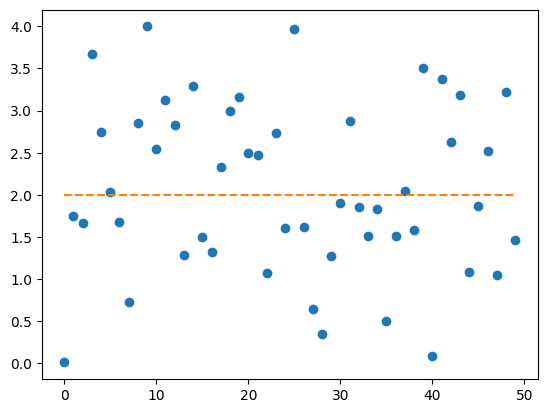

In [69]:
plt.plot(y,'o')
plt.plot(eps*0+2,'--')

`#`

`# 예제` -- ${\bf x}=[1,2,\dots,50]$에 대하여, 다음 모형에서 관측값을 생성하라. 

$$y_i = 2 + 3x_i + \epsilon_i, \quad \epsilon_i \overset{i.i.d.}{\sim} {\cal N}(0,1), \quad i=1,2,\dots,5$$

(풀이)

In [70]:
x = torch.arange(1,11)
eps = torch.randn(10)
y = 2+1.5*x + eps

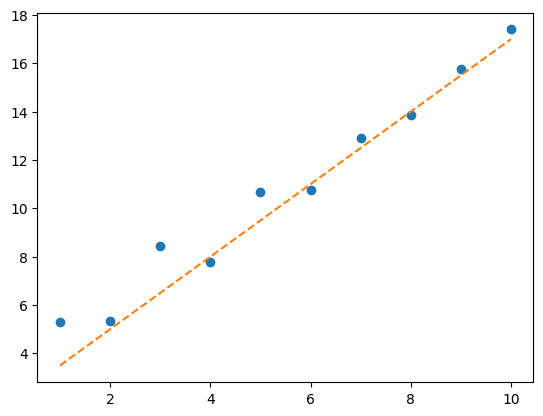

In [71]:
plt.plot(x,y,'o') # with random
plt.plot(x,2+1.5*x,'--') # without random

`#`

### `bernoulli`

> ref: <https://docs.pytorch.org/docs/stable/generated/torch.bernoulli.html>

`-` 사용시 주의점: 아래와 같이 확률에 해당하는 값을 꼭 tensor로 전달해야함

In [72]:
torch.bernoulli(0.5)

TypeError: bernoulli(): argument 'input' (position 1) must be Tensor, not float

In [73]:
torch.bernoulli(torch.tensor(0.5))

tensor(0.)

`# 예제` -- 다음 모형에서 관측값을 생성하라. 

$$y_i \overset{i.i.d.}{\sim} \text{Bernoulli}(0.5), \quad i=1,2,\dots,100$$

(풀이)

In [74]:
p = torch.tensor([0.5]*100)
y = torch.bernoulli(p)
y

tensor([0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0.,
        0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
        0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
        1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 1., 0., 1., 1., 1., 1., 1.])

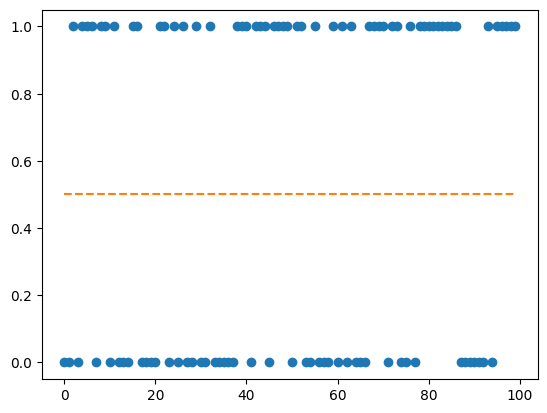

In [75]:
plt.plot(y,'o')
plt.plot(p,'--')

*(별해): 이런식으로 할 수도 있어요*

In [76]:
y = (torch.rand(100) < 0.5).float()
y

tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1.,
        1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1.,
        1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1.,
        1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0.,
        1., 0., 0., 1., 1., 0., 0., 1., 0., 0.])

`#`

`# 예제` -- 다음 모형에서 관측값을 생성하라. 

$$y_i \overset{i.i.d.}{\sim} \text{Bernoulli}(p_i), \quad p_i=\begin{cases}0.1 & i=1,2,\dots,50 \\ 0.9 & i=51,52,\dots,100 \end{cases}$$

`(풀이)`

In [77]:
p = torch.tensor([0.1]*50 + [0.9]*50)
y = torch.bernoulli(p)

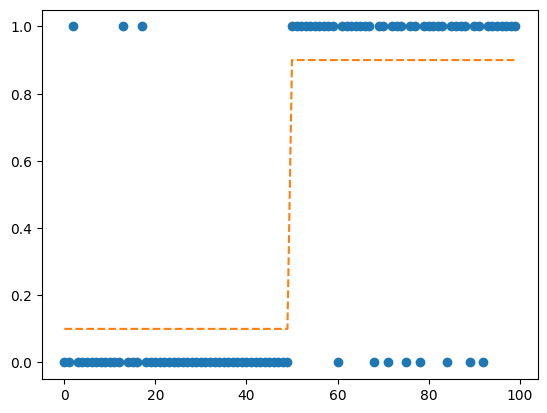

In [78]:
plt.plot(y,'o')
plt.plot(p,'--')

`#`

`# 예제` -- ${\bf x}=[-1.0,-0.9 \dots, 0.9,1.0]$ 일때, 다음 모형에서 관측값을 생성하라. 

$$y_i \overset{i.i.d.}{\sim} \text{Bernoulli}(p_i), \quad p_i=\frac{\exp(6x_i+0.5)}{\exp(6x_i+0.5)+1}$$

`(풀이)`

In [79]:
x

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

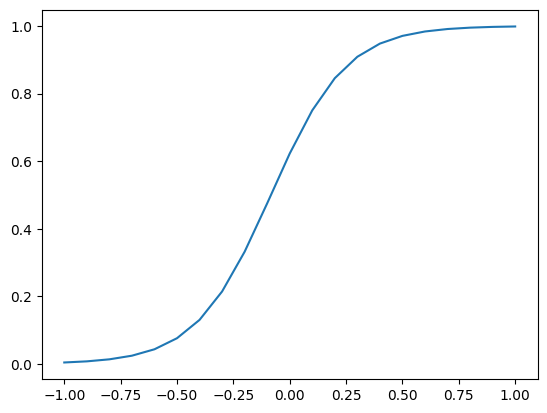

In [80]:
x = torch.arange(-10,11)/10
p = torch.exp(6*x +0.5) / (torch.exp(6*x + 0.5) + 1)
plt.plot(x,p)

In [81]:
y = torch.bernoulli(p)
y

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1.])

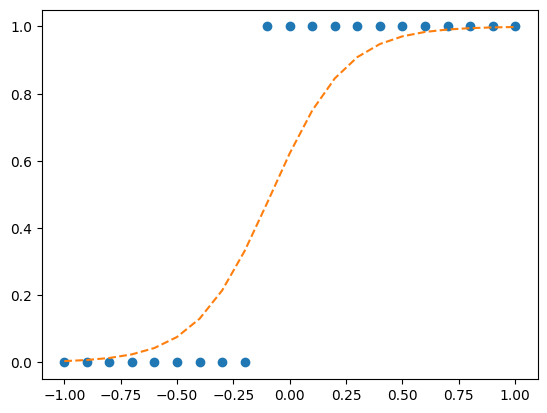

In [82]:
plt.plot(x,y,'o')
plt.plot(x,p,'--')

`#`

### `manual_seed`

`-` 아래를 여러번 실행해보자. 

In [83]:
torch.rand(10)

tensor([0.3975, 0.0547, 0.9363, 0.3878, 0.4375, 0.1521, 0.2389, 0.3139, 0.2930,
        0.5170])

`-` 이번에는 아래를 여러번 실행해보자. 

In [84]:
torch.manual_seed(43052)
torch.rand(10)

tensor([0.3267, 0.0765, 0.6802, 0.9668, 0.7037, 0.0558, 0.6629, 0.1893, 0.3704,
        0.8122])

## H. `axis`

### `concat`

`-` 기본예제 

In [85]:
a = torch.tensor([1,2]) 
b = -a

In [86]:
torch.concat([a,b]) 

tensor([ 1,  2, -1, -2])

`-` 응용 

In [87]:
a = torch.tensor([1,2])
b = -a 
c = torch.tensor([3,4,5])

In [88]:
torch.concat([a,b,c])

tensor([ 1,  2, -1, -2,  3,  4,  5])

- 여기까진 딱히 칸캐터네이트의 메리트가 없어보임
- 리스트였다면 a+b+c 하면 되는 기능이니까? 

`-` 2d array에 적용해보자. 

In [89]:
a = torch.arange(4).reshape(2,2) 
b = -a

In [90]:
torch.concat([a,b]) 

tensor([[ 0,  1],
        [ 2,  3],
        [ 0, -1],
        [-2, -3]])

`-` 옆으로 붙일려면? 

In [91]:
torch.concat([a,b],axis=1)

tensor([[ 0,  1,  0, -1],
        [ 2,  3, -2, -3]])

`-` 위의 코드에서 axis=1 이 뭐지? axis=0,2 등을 치면 결과가 어떻게 될까? 

In [92]:
torch.concat([a,b],axis=0)

tensor([[ 0,  1],
        [ 2,  3],
        [ 0, -1],
        [-2, -3]])

- 이건 그냥 torch.concat([a,b])와 같다. 
- torch.concat([a,b])는 torch.concat([a,b],axis=0)의 생략버전이군? 

In [93]:
torch.concat([a,b],axis=2)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

- 이런건 없다. 

`-` axis의 의미가 뭔지 궁금함. 좀 더 예제를 살펴보자. 

In [94]:
a = torch.arange(2*3*4).reshape(2,3,4)
a

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [95]:
b = -a
b

tensor([[[  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [96]:
torch.concat([a,b],axis=0) 

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23]],

        [[  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [97]:
torch.concat([a,b],axis=1) 

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11],
         [  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23],
         [-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [98]:
torch.concat([a,b],axis=2) 

tensor([[[  0,   1,   2,   3,   0,  -1,  -2,  -3],
         [  4,   5,   6,   7,  -4,  -5,  -6,  -7],
         [  8,   9,  10,  11,  -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15, -12, -13, -14, -15],
         [ 16,  17,  18,  19, -16, -17, -18, -19],
         [ 20,  21,  22,  23, -20, -21, -22, -23]]])

- 이번에는 axis=2까지 된다? 

In [99]:
torch.concat([a,b],axis=3) 

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got 3)

- axis=3까지는 안된다? 

`-` 뭔가 나름의 방식으로 합쳐지는데 원리가 뭘까? 

(분석1) torch.concat([a,b],axis=0) 

In [100]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [101]:
a.shape, b.shape, np.concatenate([a,b],axis=0).shape

NameError: name 'np' is not defined

- 첫번째차원이 바뀌었다 => 첫번째 축이 바뀌었다 => axis=0 (파이썬은 0부터 시작하니까!) 

(분석2) torch.concat([a,b],axis=1) 

In [102]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [103]:
a.shape, b.shape, torch.concat([a,b],axis=1).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 6, 4]))

- 두번째차원이 바뀌었다 => 두번째 축이 바뀌었다 => axis=1

(분석3) torch.concatenate([a,b],axis=2) 

In [107]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [109]:
a.shape, b.shape, torch.concat([a,b],axis=2).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 3, 8]))

- 세번째차원이 바뀌었다 => 세번째 축이 바뀌었다 => axis=2

(분석4) torch.concat([a,b],axis=3) 

In [110]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [111]:
a.shape, b.shape, torch.concat([a,b],axis=3).shape

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got 3)

- 네번째차원이 없다 => 네번째 축이 없다 => axis=3으로 하면 에러가 난다. 

(보너스1) 

In [112]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [113]:
torch.concat([a,b],axis=-1)

tensor([[[  0,   1,   2,   3,   0,  -1,  -2,  -3],
         [  4,   5,   6,   7,  -4,  -5,  -6,  -7],
         [  8,   9,  10,  11,  -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15, -12, -13, -14, -15],
         [ 16,  17,  18,  19, -16, -17, -18, -19],
         [ 20,  21,  22,  23, -20, -21, -22, -23]]])

In [114]:
a.shape, b.shape, torch.concat([a,b],axis=-1).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 3, 8]))

- 마지막 차원이 바뀌었다 => 마지막 축이 바뀌었다 => axis = -1 

(보너스2) 

In [116]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [118]:
torch.concat([a,b],axis=-2)

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11],
         [  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23],
         [-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [119]:
a.shape, b.shape, torch.concat([a,b],axis=-2).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 6, 4]))

- 마지막에서 2번째 차원이 바뀌었다 => 마지막에서 2번째 축이 바뀌었다 => axis = -2 

(보너스3) 

In [120]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [122]:
torch.concat([a,b],axis=-3)

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23]],

        [[  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [123]:
a.shape, b.shape, torch.concat([a,b],axis=-3).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([4, 3, 4]))

- 마지막에서 3번째 차원이 바뀌었다 => 마지막에서 3번째 축이 바뀌었다 => axis = -3 

(보너스4) 

In [124]:
a = torch.arange(2*3*4).reshape(2,3,4) 
b = -a 

In [125]:
torch.concat([a,b],axis=-4)

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got -4)

- 마지막에서 4번째 차원은 없다 => 마지막에서 4번째 축이 없다 => axis = -4는 에러가 난다. 

`-` 0차원은 축이 없으므로 concat을 쓸 수 없다. 

In [127]:
a = torch.tensor(1)
b = torch.tensor(-1) 

In [128]:
a.shape, b.shape

(torch.Size([]), torch.Size([]))

In [129]:
torch.concat([a,b])

RuntimeError: zero-dimensional tensor (at position 0) cannot be concatenated

`-` 꼭 a,b가 같은 차원일 필요는 없다. 

In [130]:
a = torch.arange(4).reshape(2,2) 
b = torch.arange(2).reshape(2,1)  

In [131]:
torch.concat([a,b],axis=1)

tensor([[0, 1, 0],
        [2, 3, 1]])

In [132]:
a.shape, b.shape, torch.concat([a,b],axis=1).shape

(torch.Size([2, 2]), torch.Size([2, 1]), torch.Size([2, 3]))

### `stack`

`-` 혹시 아래가 가능할까? 

- (3) 결합 (3) => (3,2) 

In [133]:
a = torch.tensor([1,2,3])
b = -a

In [134]:
a,b

(tensor([1, 2, 3]), tensor([-1, -2, -3]))

In [135]:
torch.concat([a,b],axis=1)

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

- 불가능 

`-` 아래와 같이 하면 해결가능 

In [136]:
a = torch.tensor([1,2,3]).reshape(3,1) 
b = -a

In [137]:
a,b

(tensor([[1],
         [2],
         [3]]),
 tensor([[-1],
         [-2],
         [-3]]))

In [139]:
torch.concat([a,b],axis=1)

tensor([[ 1, -1],
        [ 2, -2],
        [ 3, -3]])

- 분석: (3) (3) => (3,1) (3,1) => (3,1) concat (3,1) 

`-` 위의 과정을 줄여서 아래와 같이 할 수 있다. 

In [140]:
a = torch.tensor([1,2,3])
b = -a

In [141]:
torch.stack([a,b],axis=1)

tensor([[ 1, -1],
        [ 2, -2],
        [ 3, -3]])

`-` 아래도 가능 

In [142]:
torch.stack([a,b],axis=0)

tensor([[ 1,  2,  3],
        [-1, -2, -3]])

`-` 분석해보고 외우자

(분석1)

In [144]:
a = torch.tensor([1,2,3])
b = -a

In [146]:
a.shape, b.shape, torch.stack([a,b],axis=0).shape

(torch.Size([3]), torch.Size([3]), torch.Size([2, 3]))

- (3) (3) => 첫 위치에 축을 추가 (axis=0) => (1,3) (1,3) => (2,3) 

(분석2)

In [147]:
a = torch.tensor([1,2,3])
b = -a

In [149]:
a.shape, b.shape, torch.stack([a,b],axis=1).shape

(torch.Size([3]), torch.Size([3]), torch.Size([3, 2]))

- (3) (3) => 두 위치에 축을 추가 (axis=1) => (3,1) (3,1) => (3,2) 

`-` 고차원예제 

In [150]:
a = torch.arange(3*4*5).reshape(3,4,5) 
b = -a

In [151]:
a.shape, b.shape

(torch.Size([3, 4, 5]), torch.Size([3, 4, 5]))

In [152]:
torch.stack([a,b],axis=0).shape # (3,4,5) => (1,3,4,5) // 첫 위치에 축이 추가되고 스택 

torch.Size([2, 3, 4, 5])

In [153]:
torch.stack([a,b],axis=1).shape # (3,4,5) => (3,1,4,5) // 두번째 위치에 축이 추가되고 스택 

torch.Size([3, 2, 4, 5])

In [154]:
torch.stack([a,b],axis=2).shape # (3,4,5) => (3,4,1,5) // 세번째 위치에 축이 추가되고 스택 

torch.Size([3, 4, 2, 5])

In [155]:
torch.stack([a,b],axis=3).shape # (3,4,5) => (3,4,5,1) // 네번째 위치에 축이 추가되고 스택 

torch.Size([3, 4, 5, 2])

In [156]:
torch.stack([a,b],axis=-1).shape # axis=-1 <=> axis=3 

torch.Size([3, 4, 5, 2])

In [157]:
torch.stack([a,b],axis=-2).shape # axis=-2 <=> axis=2

torch.Size([3, 4, 2, 5])

***torch.concat***은 축의 총 갯수를 유지하면서 결합, ***torch.stack***은 축의 갯수를 하나 증가시키면서 결합

### `sum`

`-` 1차원 

In [158]:
a = torch.tensor([1,2,3]) 
a

tensor([1, 2, 3])

In [159]:
a.sum()

tensor(6)

In [160]:
a.sum(axis=0)

tensor(6)

`-` 2차원 

In [161]:
a = torch.arange(6).reshape(2,3)
a

tensor([[0, 1, 2],
        [3, 4, 5]])

In [162]:
a.sum() # 전체합

tensor(15)

In [163]:
a.sum(axis=0) 

tensor([3, 5, 7])

In [164]:
a.sum(axis=1) 

tensor([ 3, 12])

`-` 2차원 결과 분석 

In [165]:
a.shape, a.sum(axis=0).shape

(torch.Size([2, 3]), torch.Size([3]))

- 첫번째 축이 삭제됨 => axis=0 

In [166]:
a.shape, a.sum(axis=1).shape

(torch.Size([2, 3]), torch.Size([2]))

- 두번째 축이 삭제됨 => axis=1 

`# 예제` -- 아래의 텐서를 고려하자. 

In [167]:
a = torch.arange(10).reshape(5,2) 
a

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

`(1)` -- 1열의 합, 2열의 합을 계산하고 싶다면? 

(풀이) 차원이 (5,2) => (2,) 로 나와야 한다. (그럼 첫번째 축이 삭제되어야 하네?) 

In [168]:
a.sum(axis=0)

tensor([20, 25])

`(2)` 1행의 합, 2행의 합, ... , 5행의 합을 계산하고 싶다면? 

(풀이) 차원이 (5,2) => (5,)로 나와야 한다. (그럼 두번째 축이 삭제되어야 하네?) 

In [169]:
a.sum(axis=1)

tensor([ 1,  5,  9, 13, 17])

`(3)` a의 모든원소의 합을 계산하고 싶다면? 

(풀이) 차원이 (5,2) => () 로 나와야 한다. (첫번째축, 두번째축이 모두 삭제되어야 하네?) 

In [170]:
a.sum(axis=(0,1))

tensor(45)

In [171]:
a.sum() # 즉 a.sum(axis=(0,1))이 디폴트값임 

tensor(45)

`#`

### `mean`, `max`, `min`

`-` 모두 sum이랑 유사한 논리 

In [175]:
a = torch.arange(10).reshape(5,2).float()
a

tensor([[0., 1.],
        [2., 3.],
        [4., 5.],
        [6., 7.],
        [8., 9.]])

`axis=0`

In [193]:
a.mean(axis=0)

tensor([4., 5.])

In [194]:
a.max(axis=0)[0]

tensor([8., 9.])

In [195]:
a.min(axis=0)[0]

tensor([0., 1.])

`axis=1`

In [196]:
a.mean(axis=1), a.max(axis=1)[0], a.min(axis=1)[0]

(tensor([0.5000, 2.5000, 4.5000, 6.5000, 8.5000]),
 tensor([1., 3., 5., 7., 9.]),
 tensor([0., 2., 4., 6., 8.]))

### `argmax`, `argmin`

`-` 1차원 

In [197]:
a = torch.tensor([1,-2,3,10,4])
a

tensor([ 1, -2,  3, 10,  4])

In [198]:
a.argmax() # 가장 큰 값이 위치한 원소의 인덱스를 리턴 

tensor(3)

In [199]:
a.argmin() # 가장 작은 값이 위치한 원소의 인덱스를 리턴 

tensor(1)

`-` 2차원 

In [203]:
torch.manual_seed(43052)
a = torch.randn(4*5).reshape(4,5)
a

tensor([[-0.6103,  0.1521,  1.5031,  0.1420, -0.9469],
        [-0.4710, -0.3719,  1.1024,  0.3593, -0.3465],
        [ 2.0675,  0.1851, -0.5830, -1.4509,  0.1568],
        [-1.4435,  1.4436,  0.4114, -0.8609,  1.5440]])

In [204]:
a.argmin(), a.min()

(tensor(13), tensor(-1.4509))

In [205]:
a.argmax(), a.max()

(tensor(10), tensor(2.0675))

In [206]:
a.argmin(axis=0), a.argmin(axis=1)

(tensor([3, 1, 2, 2, 0]), tensor([4, 0, 3, 0]))

In [207]:
a.argmax(axis=0), a.argmax(axis=1)

(tensor([2, 3, 0, 1, 3]), tensor([2, 2, 0, 4]))

## I. 응용문제: `MNIST`